[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeyerBender/segtraq_workshop/blob/main/notebooks/solution.ipynb)

# QC for Cell Segmentation with SpatialData and SegTraQ

Assessing the quality of cell segmentation in spatial transcriptomics (ST) data is much trickier than in images. In ST data, we do not only care about accurately capturing cellular morphology, but we also want to avoid contamination from transcripts that diffuse outside of their cell of origin. `SegTraQ` (**Seg**mentation and **Tra**nscript Assignment **Q**uality Assessment) provides metrics to assess exactly this, and can be used to identify spurious samples, cells, or to compare segmentation methods. In this workshop, we will have a look at some CosMx samples taken from [Lermi et al.](https://www.nature.com/articles/s41467-025-63414-1). We will use `spatialdata` to read in the data, `spatialdata-plot` to visualize it, and `SegTraQ` to assess how well segmentation worked for those samples.

In [1]:
# download the data
# if you have already run this cell once, there is no need to run it again

# use this when running on colab
! wget --no-check-certificate -O /content/data.tar.gz https://oc.embl.de/index.php/s/jOslJpJngeKxTJF/download
! tar -xzf /content/data.tar.gz
! pip install --quiet segtraq==0.0.7 spatialdata==0.8.0 spatialdata_plot==0.4.2 anndata==0.12.8 seaborn==0.13.2 pandas==2.2.3
data_dir = '/content/data'

# use this when running locally (or on a cluster)
#! wget --no-check-certificate -O data.tar.gz https://oc.embl.de/index.php/s/jOslJpJngeKxTJF/download
#! tar -xzf data.tar.gz
#data_dir = 'data'

--2026-10-07 12:08:02--  https://oc.embl.de/index.php/s/jOslJpJngeKxTJF/download
Resolving oc.embl.de (oc.embl.de)... 10.11.5.116
Connecting to oc.embl.de (oc.embl.de)|10.11.5.116|:443... connected.
  Self-signed certificate encountered.
HTTP request sent, awaiting response... 200 OK
Length: 667003605 (636M) [application/gzip]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>] 636.10M   152MB/s    in 4.2s    

2026-10-07 12:08:07 (151 MB/s) - ‘data.tar.gz’ saved [667003605/667003605]



In [2]:
# importing required packages
import spatialdata as sd
import spatialdata_plot
import segtraq
import pandas as pd
import seaborn as sns
import warnings
import anndata as ad
import matplotlib.pyplot as plt
import os

# setting segtraq to use the maximum amount of cores for parallelization
segtraq.settings.n_jobs = -1

# 1. Getting started

Before we can do anything with the data, we need to get it into `spatialdata` format. `Spatialdata-io` provides readers that do this for various technologies. For convenience, the data provided with this workshop is already in `spatialdata` format, so we can simply read it using `sd.read_zarr()`.

In [3]:
sd_dict = dict()
fovs = [5, 18, 24, 29, 44]
for fov in fovs:
    sd_dict[fov] = sd.read_zarr(os.path.join(data_dir, f'cosmx_fovs/GSM9046088_Lung_Adenocarcinoma_TMA1_CosMx_{fov}.zarr'))

Let's have a look at what these objects look like. We use FOV 44 as an example `sdata` object.

In [4]:
sdata = sd_dict[44]
sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/segtraq_workshop/notebooks/data/cosmx_fovs/GSM9046088_Lung_Adenocarcinoma_TMA1_CosMx_44.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (378730, 10) (2D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (1011, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (1011, 1010)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes)

We can use the name of each layer to access it. For example, let's look at the table.

In [5]:
sdata["table"]

AnnData object with n_obs × n_vars = 1011 × 1010
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'global'

We can also go further and look at the `obs` directly.

In [6]:
sdata["table"].obs.head()

,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,Mean.B2M.MembraneStain,Max.B2M.MembraneStain,Mean.CD45,Max.CD45,Mean.DAPI,Max.DAPI,fov_labels,cell_ID,region
1_44,44,8009,2.05,135,66,155,390,0,25,139,436,0,151,199,1104,44_shapes,1,cell_boundaries
2_44,44,9094,1.26,122,97,243,576,1,227,215,710,2,401,298,1537,44_shapes,2,cell_boundaries
3_44,44,8271,2.04,149,73,95,371,0,17,126,726,0,68,363,1536,44_shapes,3,cell_boundaries
4_44,44,6013,1.24,97,78,93,1050,1,216,198,772,3,218,473,1593,44_shapes,4,cell_boundaries
5_44,44,6677,1.09,101,93,53,597,26,887,161,656,0,85,321,1610,44_shapes,5,cell_boundaries


Let's also quickly have a look at what the transcripts and cell boundaries look like.

In [7]:
sdata["transcripts"].head()

,x,y,target,cell_ID,y_global_px,CellComp,z_raw,Unnamed: 0,x_global_px,fov
0,555.120,4232.9400,IGKC,0,-47567.0600,<NA>,0,22914771,-462028.213333,44
1,1900.380,4232.8400,CD74,0,-47567.1600,<NA>,0,22914772,-460682.953333,44
2,464.622,4224.1222,APOE,0,-47575.8778,<NA>,0,22914773,-462118.711333,44
3,1892.280,4218.7000,CCL2,0,-47581.3000,<NA>,0,22914774,-460691.053333,44
4,683.900,4169.9571,IGKC,0,-47630.0429,<NA>,0,22914775,-461899.433333,44


In [8]:
sdata["cell_boundaries"].head()

,fov,cellID,geometry
0,44,1,"POLYGON ((221 4191, 196 4192, 181 4193, 176 41..."
1,44,10,"POLYGON ((3086 3900, 3084 3901, 3073 3912, 305..."
2,44,100,"POLYGON ((2869 3132, 2864 3134, 2862 3135, 285..."
3,44,1000,"POLYGON ((1625 275, 1616 278, 1610 281, 1604 2..."
4,44,1001,"POLYGON ((2173 259, 2164 262, 2147 268, 2145 2..."


# 2. Plotting the data

Now that we have a feel for the data, we can try to plot some things. To do this, we use `spatialdata-plot`. Let's start by plotting some cells and transcripts.

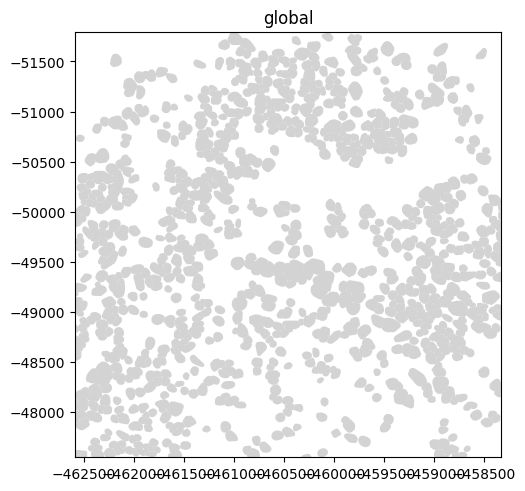

In [9]:
sdata.pl.render_shapes().pl.show()

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


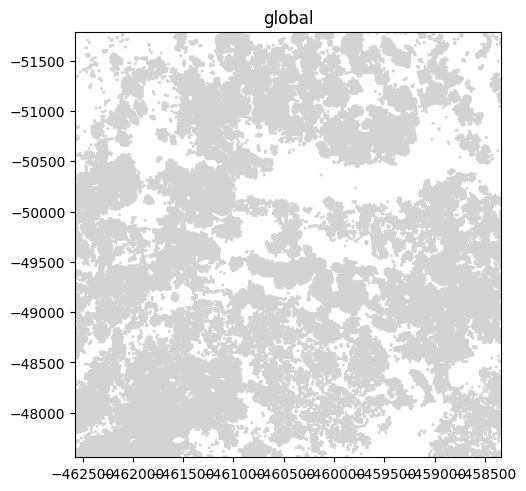

In [10]:
sdata.pl.render_points().pl.show()

We can also plot them on top of one another. For simplicity, we now only look at a couple of genes.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


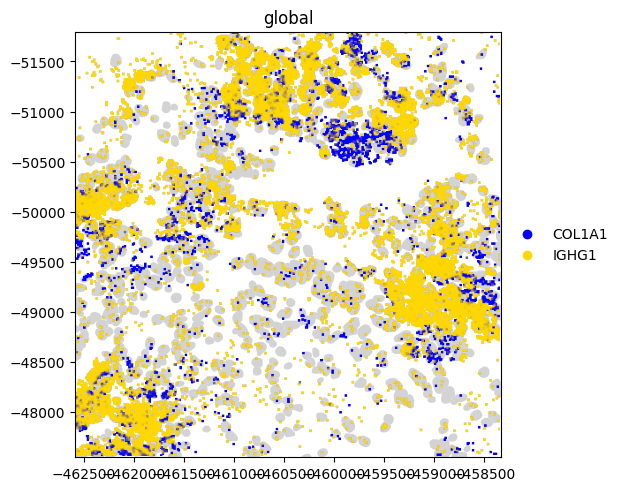

In [11]:
(sdata.pl.render_shapes()
      .pl.render_points(color='target', groups=["COL1A1", "IGHG1"], palette=["blue", "gold"])
      .pl.show())

# 3. Loading the data into SegTraQ

One common issue with spatial transcriptomics data is that each vendor calls things differently. For example, some technologies have a `gene` column, others call it `target`. One technology might have `x`, the other one `x-centroid`, and so on. Even within a single `spatialdata` object, there can be inconsistencies. For example, cells are identifies via `cell_ID` in the transcripts data frame, but called `cellID` in the cell boundaries.


We do not want to define this every time we compute a metric. To deal with this, `SegTraQ` uses a constructor where you define these parameters once. Try using `segtraq.SegTraQ(sdata)` to load the data. **This will initially raise an error,** because you need to define additional keywords. Give it a try, and see which parameters you need to specify to get it working.

In [12]:
st = segtraq.SegTraQ(sdata,
                    images_key=None,
                    points_cell_id_key='cell_ID',
                    points_z_key='z_raw',
                    points_gene_key='target',
                    shapes_cell_id_key='cellID',
                    points_background_id=0,
                    tables_cell_id_key='cell_ID',
                    tables_area_key='Area',
                    tables_centroid_x_key=None,
                    tables_centroid_y_key=None,
                    nucleus_shapes_key=None,
                    points_qv_key=None
                    )

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1862: UserWarning: Setting column 'cellID' as the index for shapes 'cell_boundaries', as this is required to link the table to shapes in SpatialData.
  shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:160: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:188: UserWarning: Filtering control probes matching prefixes ('NegControlProbe_', 'antisense_', 'NegControlCodeword', 'BLANK_', 'Blank-', 'NegPrb', 'DeprecatedCodeword_', 'UnassignedCodeword_', 'Intergenic_Region_') and transcripts with qv < 20 from transcript points in-place; control probes are also removed from the expression table if present. Configure `min_qv`, `control_prefixes`, and `inplace` via `filter_kwargs`.
  

As you can see, there are some warnings. These tell you that negative control probes were filtered out, and that there are some cells with 0 counts. We can ignore those for now. Let's now convert all of our `spatialdata` objects into `SegTraQ`.

In [13]:
st_dict = dict()

for fov, sdata in sd_dict.items():
    # we ignore warnings here
    # this is done for demonstration purposes only
    # always check what the warnings say and if it indicates a problem with your data
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        st_dict[fov] = segtraq.SegTraQ(sdata,
                            images_key=None,
                            points_cell_id_key='cell_ID',
                            points_z_key='z_raw',
                            points_gene_key='target',
                            shapes_cell_id_key='cellID',
                            points_background_id=0,
                            tables_cell_id_key='cell_ID',
                            tables_area_key='Area',
                            tables_centroid_x_key=None,
                            tables_centroid_y_key=None,
                            nucleus_shapes_key=None,
                            points_qv_key=None
                            )

# 4. Computing some metrics
Now that we finally have the data in one consistent container, we can start to compute some metrics! Let's start with some baseline metrics, such as the number of segmented cells or the percentage of unassigned transcripts. We can compute these using `run_baseline()`.

In [14]:
for st in st_dict.values():
    st.run_baseline()

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:1537: UserWarning: The number of genes differs between points (916) and tables (1000). Example genes that are missed: ['IAPP', 'ITGAL', 'PGR', 'ACACB', 'LINC01857']. If these are control probes, please make sure to include them in the SegTraQ constructor. For example: SegTraQ(filter_kwargs={'control_prefixes': [...], 'control_genes': [...]}). Storing the number of genes from the points layer.
  return bl.num_genes(


Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

Baseline:   0%|          | 0/10 [00:00<?, ?step/s]

All results are written into the `spatialdata` object in-place, and can be found in `sdata["table"]`. Let's have a look!

In [15]:
# reassigning sdata, so that it does not get overwritten by the sdata variable in the previous for loop
sdata = sd_dict[44]

# the obs contain per-cell metrics such as the cell area, gene count, and morphological metrics
sdata["table"].obs.iloc[:5, -15:]

,centroid_x,centroid_y,gene_count,mean_transcripts_per_gene,transcript_count,transcript_density,num_polygons,cell_area,perimeter,circularity,solidity,convexity,elongation,eccentricity,compactness
1_44,222.542994,4224.725801,109.0,2.504587,273.0,0.034087,1,7956.5,353.399761,0.800570,1.0,1.0,2.061538,0.874473,15.696775
2_44,345.584004,4212.982024,155.0,3.116129,483.0,0.053112,1,9077.0,350.522796,0.928367,1.0,1.0,1.250000,0.600000,13.535995
3_44,199.973512,4163.931146,75.0,5.373333,403.0,0.048724,1,8670.5,370.349219,0.794385,1.0,1.0,2.265444,0.897303,15.818989
4_44,632.693259,4134.455772,74.0,3.932432,291.0,0.048395,1,6067.0,290.380463,0.904168,1.0,1.0,1.263158,0.610953,13.898271
5_44,914.784646,4111.175582,116.0,2.500000,290.0,0.043433,1,6730.0,295.784335,0.966662,1.0,1.0,1.136764,0.475547,12.999758


We can also have a look at some sample-level metrics, which are not stored in `obs`, but in the `uns` slot.

In [16]:
sdata["table"].uns

{'spatialdata_attrs': {'instance_key': 'cell_ID',
  'region_key': 'region',
  'region': 'cell_boundaries'},
 'num_cells': 1011,
 'num_transcripts': 378380,
 'num_genes': 1000,
 'perc_unassigned_transcripts': np.float64(18.467413711084095)}

Let's put all of these into a data frame and plot the results.

In [17]:
df = []

for fov, st in st_dict.items():
    uns = st.sdata["table"].uns
    df.append([fov, uns['num_cells'], uns['perc_unassigned_transcripts'], uns['num_transcripts']])
    
df = pd.DataFrame(df, columns=['fov', 'num_cells', 'perc_unassigned_transcripts', 'num_transcripts'])

<Axes: xlabel='num_cells', ylabel='perc_unassigned_transcripts'>

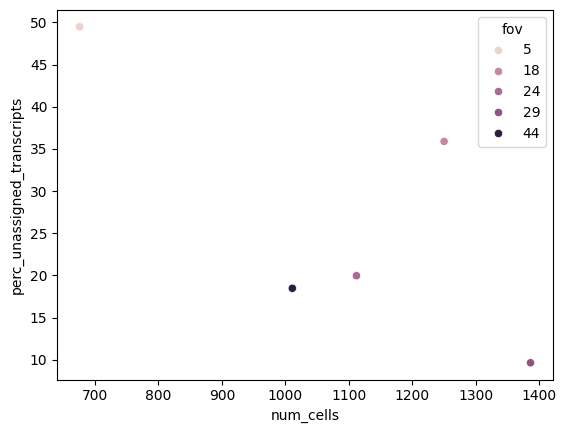

In [18]:
sns.scatterplot(df, x='num_cells', y='perc_unassigned_transcripts', hue='fov')

One of the samples has almost 50% of transcripts that are unassigned! Let's visualize this with `spatialdata-plot`.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


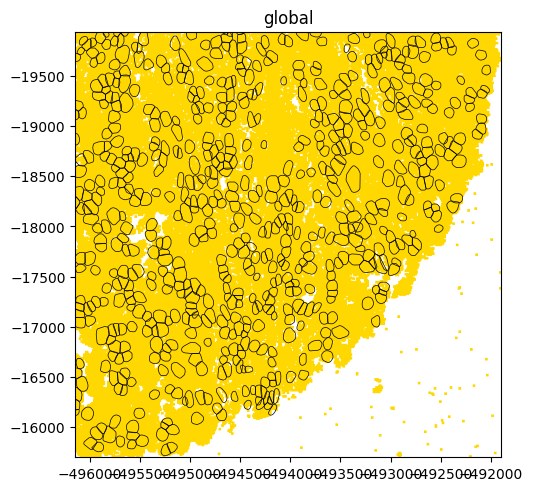

In [19]:
(sd_dict[5].pl.render_points(color='gold')
           .pl.render_shapes(fill_alpha=0, outline_alpha=1, outline_width=0.5)
           .pl.show())

You can see that there are a lot of transcripts that are free-floating in space, where no cells were segmented. This is an instance of undersegmentation!

We can also check the number of transcripts for each sample.

In [20]:
df[['fov', 'num_transcripts']]

,fov,num_transcripts
0,5,586501
1,18,4498
2,24,177480
3,29,1000918
4,44,378380


We can see that sample 18 has a surprisingly low number of transcripts. Let's check what's going on here.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


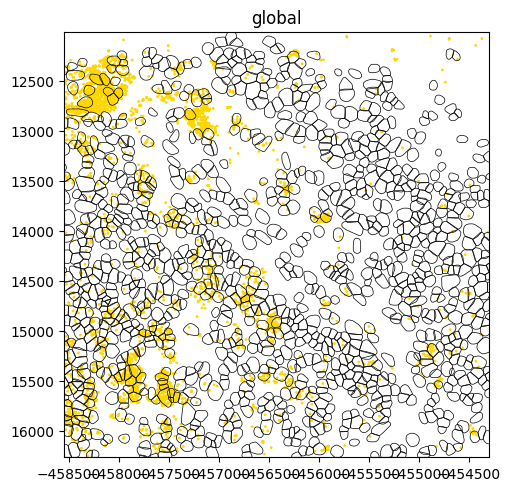

In [21]:
(sd_dict[18].pl.render_points(color='gold')
            .pl.render_shapes(fill_alpha=0, outline_alpha=1, outline_width=0.5)
            .pl.show())

Looks like transcript detection did not work in this sample! In an actual analysis setting, you would remove such a sample before performing downstream analysis.

# 5. Using scRNA-seq information
With the baseline metrics, we were already able to detect various issues with the segmentation and with the data. For the last part of this workshop, we are going to look at some more elaborate metrics that can tell us if a sample shows signs of transcript spillage between cells.

More specifically, we will now use an annotated scRNA-seq dataset to transfer cell type labels onto our spatial transcriptomics data. We then use this RNAseq data to figure out which genes should be expressed in which cell type, and check for contamination this way. The scRNA-seq data is from a publicly available dataset on [CELLxGENE](https://datasets.cellxgene.cziscience.com/a95f7e58-a8fb-4fcd-b55f-e074cdae155b.h5ad).

In [22]:
# reading the data (already in anndata format)
adata_ref = ad.read_h5ad('data/lung_adenocarcinoma_scrnaseq.h5ad')
# setting the var names to the gene symbols
adata_ref.var_names = adata_ref.var['gene_symbol'].values
adata_ref.var_names_make_unique()
adata_ref

AnnData object with n_obs × n_vars = 117266 × 57398
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

We can simply use the `run_supervised()` function to run both label transfer and the supervised metrics all in one go. Here, we only show this for one sample, but you could also compute this for all of them.

In [23]:
st_dict[44].run_supervised(adata_ref=adata_ref, ref_cell_type='author_cell_type_level_1')

Supervised:   0%|          | 0/5 [00:00<?, ?step/s]

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:1872: RuntimeWarning: neighbors_key='spatial_connectivities' not found in adata.obsp. A neighborhood graph based on Delaunay will be computed.
  return sp.marker_purity(


Before investigating the results of the metrics, we first visualize the cell types.

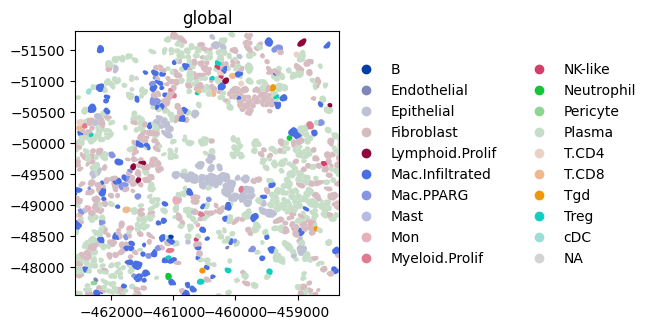

In [24]:
sdata.pl.render_shapes(color='transferred_cell_type').pl.show()

Let's focus on sample 44 again and have a look at some of the metrics, starting with the contamination strength matrix.

/tmp/ipykernel_7151/1211363218.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  cont_strength_mat.stack(dropna=False)
/tmp/ipykernel_7151/1211363218.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  plot_df["n_evaluable"] = cont_n.stack(dropna=False).values


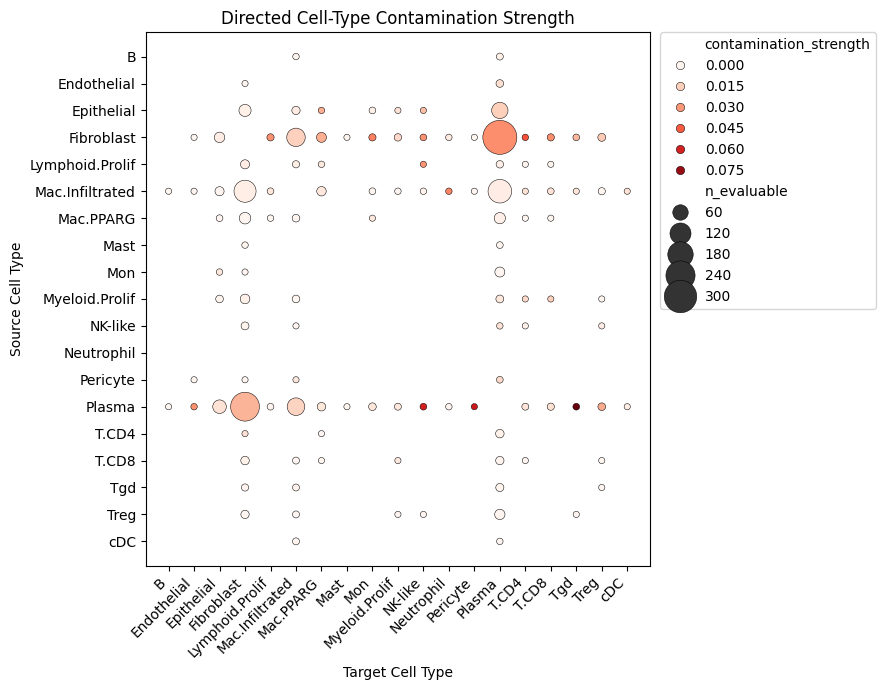

In [25]:
cont_strength_mat = sdata["table"].uns["contamination_strength_matrix"]
cont_n = sdata["table"].uns["contamination_evaluable_cells_matrix"]

plot_df = (
    cont_strength_mat.stack(dropna=False)
    .rename("contamination_strength")
    .reset_index()
    .rename(columns={"level_0": "source", "level_1": "target"})
)

plot_df["n_evaluable"] = cont_n.stack(dropna=False).values

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=plot_df,
    x="target",
    y="source",
    size="n_evaluable",
    hue="contamination_strength",
    sizes=(20, 600),
    palette="Reds",
    edgecolor="black",
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Directed Cell-Type Contamination Strength")
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

We can see a lot of contamination between fibroblasts and plasma cells. We can look at the mutually exclusive coexpression rate (MECR) to get a sense for what is going on here. The MECR provides gene pairs that should not occur within the same cell (according to the scRNA-seq reference dataset), but do.

In [26]:
mecr_df = sdata["table"].uns['mutually_exclusive_coexpression_rate']
# filtering by adjusted p-value and odds ratio
mecr_df = mecr_df[(mecr_df['pvalue_adj'] < 0.05) & (mecr_df['odds_ratio'] > 1)]
# sorting by coexpression fraction
mecr_df = mecr_df.sort_values(by='coexpression_fraction', ascending=False)
mecr_df.head(10)

,gene1,gene2,odds_ratio,pvalue,pvalue_adj,a,b,c,d,coexpression_fraction
4475,CLU,IGHG2,2.452073,3.583808e-05,1.597632e-02,143,23,606,239,0.141444
4824,COL1A1,CXCL13,2.612898,3.688845e-07,8.446776e-04,111,455,38,407,0.109792
8546,IGHG2,MEG3,2.698022,1.757500e-04,4.254822e-02,99,650,14,248,0.097923
5232,COL6A2,CXCL13,2.235087,5.235994e-06,5.092718e-03,82,305,67,557,0.081108
6176,CXCL13,LUM,3.246395,7.758718e-11,8.301053e-07,82,67,236,626,0.081108
5197,COL6A1,CXCL13,2.194339,8.554216e-06,6.537254e-03,80,298,69,564,0.079130
6125,CXCL13,DCN,2.384189,1.180712e-06,1.804634e-03,76,73,262,600,0.075173
6203,CXCL13,RARRES2,2.008075,7.694242e-05,2.695777e-02,74,75,284,578,0.073195
6214,CXCL13,TAGLN,2.728689,3.861977e-08,2.065965e-04,72,77,220,642,0.071217
5152,COL5A3,IGHG2,3.376662,2.227031e-04,4.254822e-02,72,8,677,254,0.071217


We can once again visualize the results spatially.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.

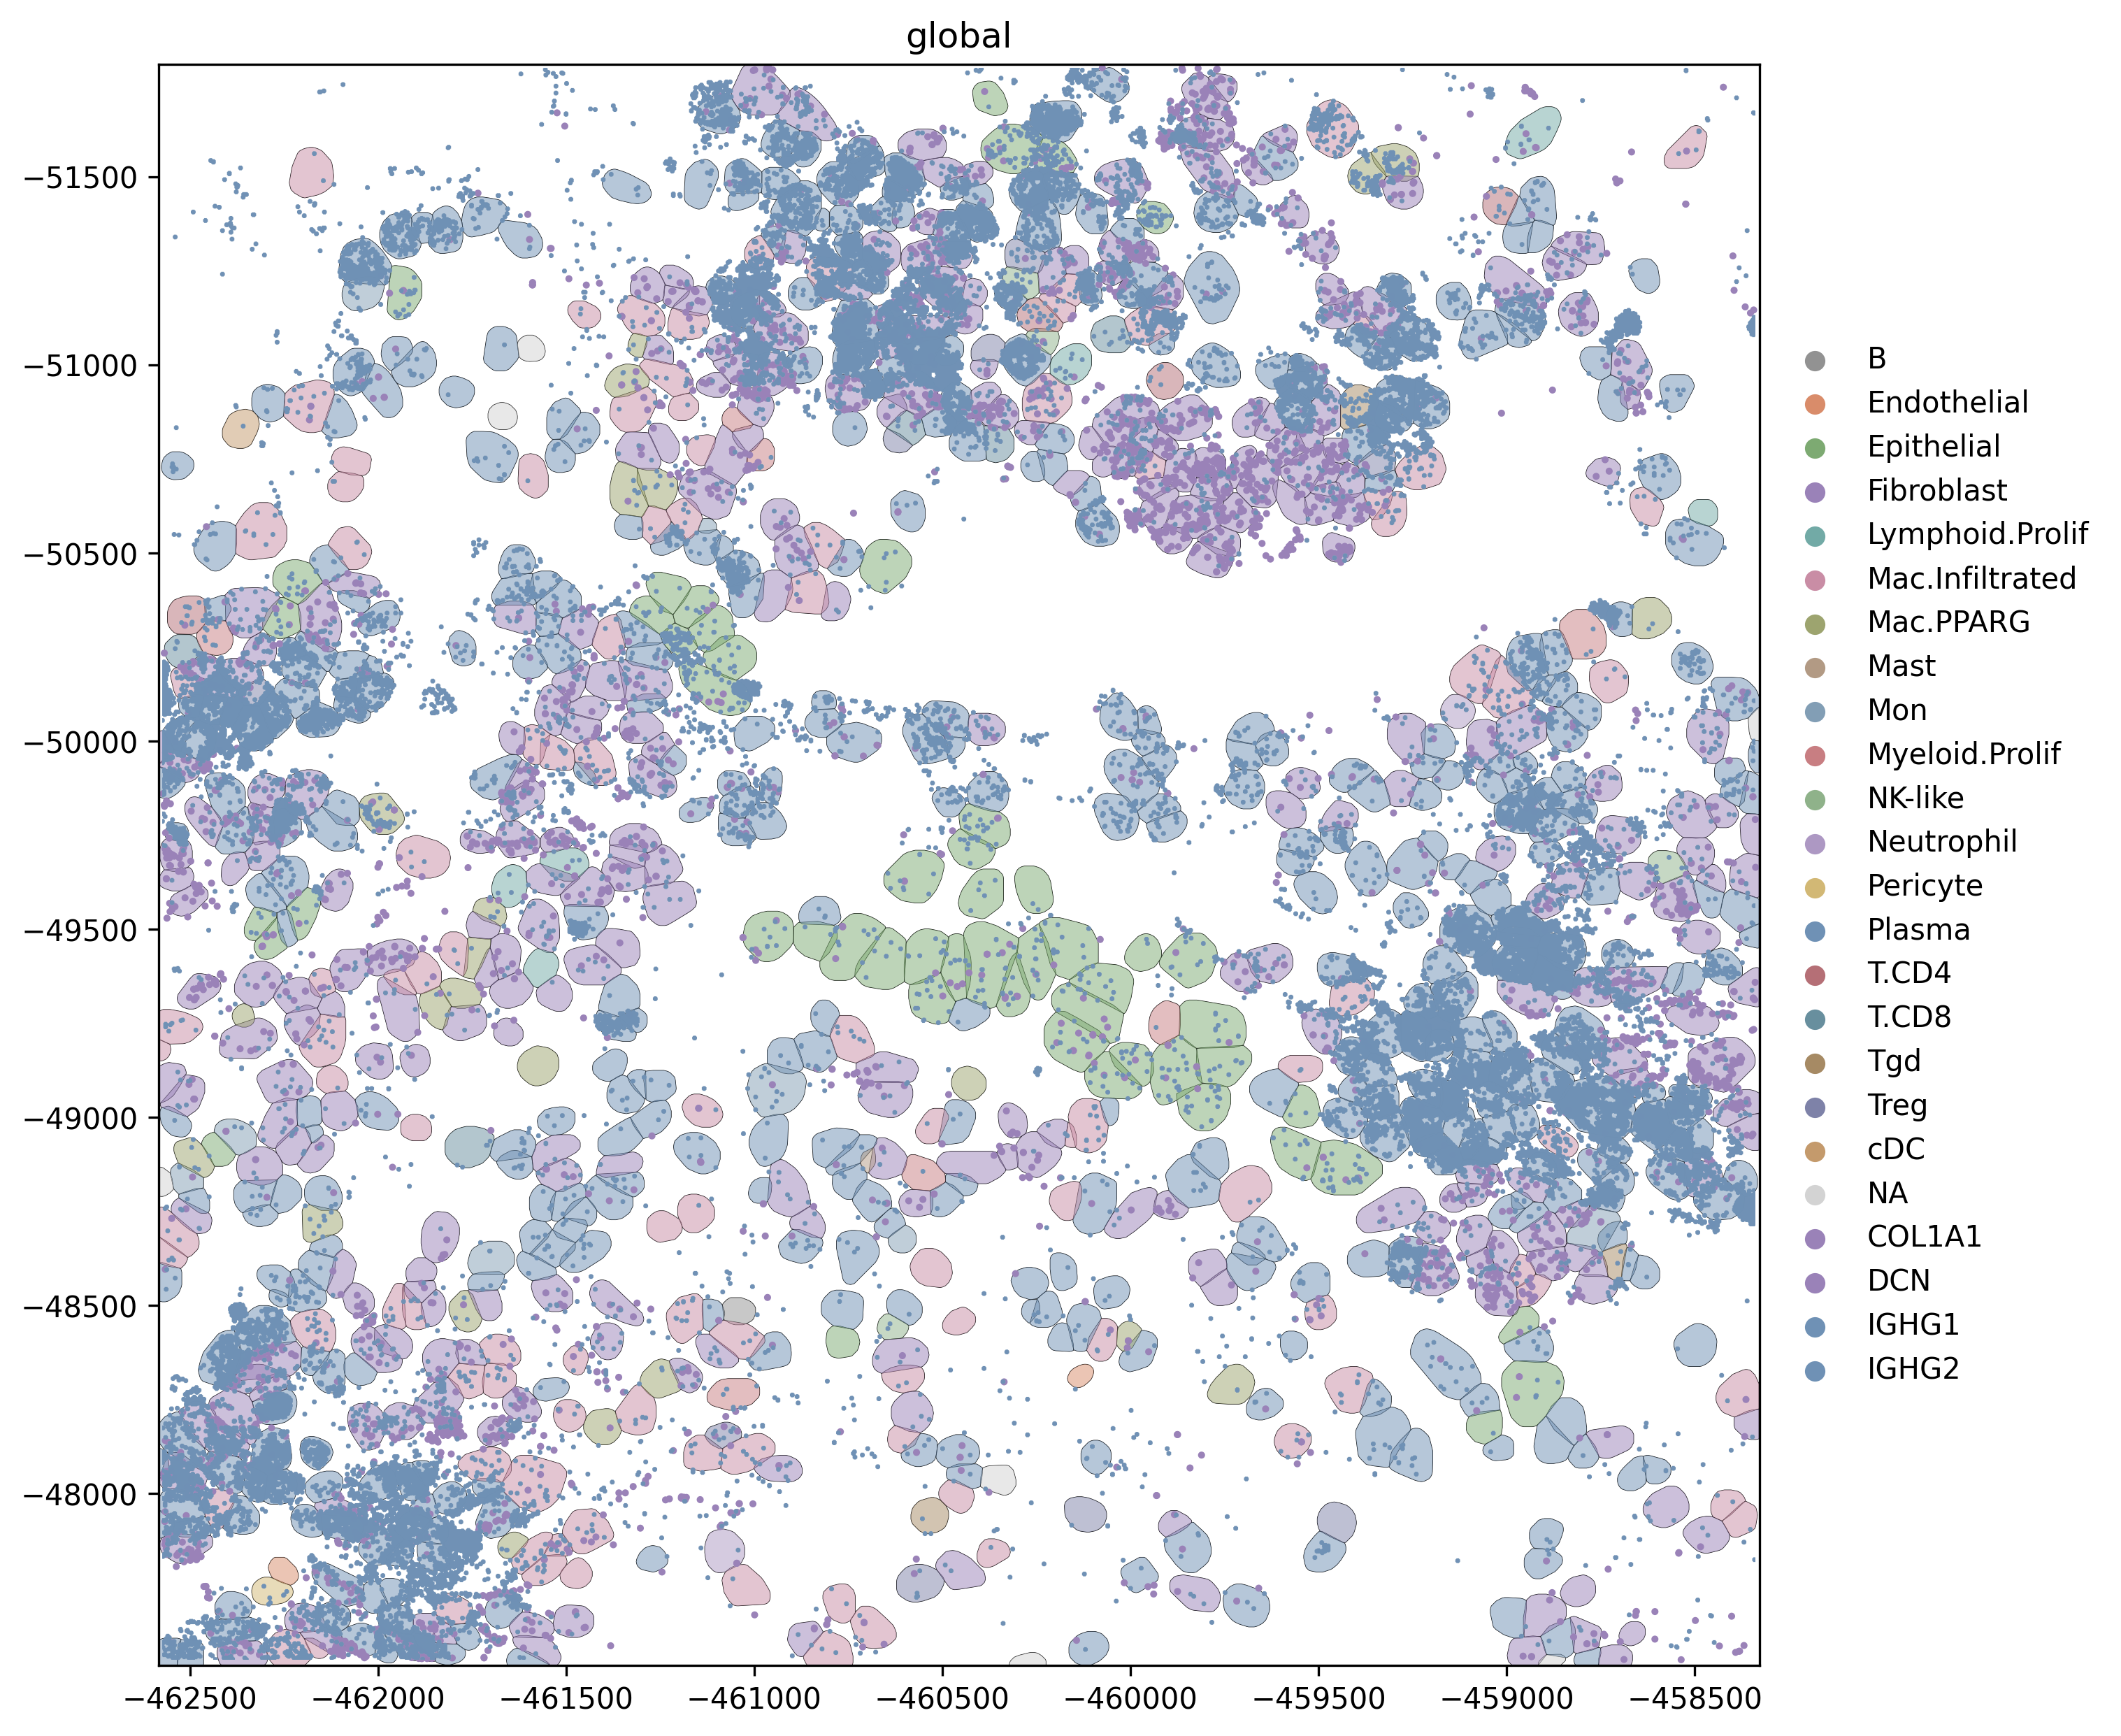

In [27]:
CELLTYPE_COLORS = {
    "B":               "#929292",  # grey
    "Endothelial":     "#D98C6A",  # terracotta
    "Epithelial":      "#7DAA72",  # green
    "Fibroblast":      "#9A82B8",  # purple
    "ILC":             "#D5A85A",  # ochre
    "Lymphoid.Prolif": "#72AAA6",  # teal
    "Mac.Infiltrated": "#C98DA5",  # rose
    "Mac.PPARG":       "#9DA46F",  # olive
    "Mast":            "#B29A84",  # taupe
    "Mon":             "#829EB5",  # blue-grey
    "Myeloid.Prolif":  "#C87E82",  # muted red
    "NK-like":         "#8FB28A",  # sage
    "Neutrophil":      "#AD98C3",  # lavender
    "Pericyte":        "#D2B875",  # sand
    "Plasma":          "#6F91B5",  # blue
    "T.CD4":           "#B56F76",  # dusty red
    "T.CD8":           "#688F9E",  # slate teal
    "Tgd":             "#A68A64",  # warm brown
    "Treg":            "#7E82A8",  # muted indigo
    "cDC":             "#C49A6C",  # tan
    "pDC":             "#6F9B8C",  # muted sea green
    "Unassigned":      "#D3D3D3",  # light grey
}

(sdata.pl.render_shapes(color='transferred_cell_type', palette=CELLTYPE_COLORS, fill_alpha=0.5, outline_color="black", outline_width=0.2)
      .pl.render_points(color='target', groups=["COL1A1", "DCN"], palette=["#9A82B8", "#9A82B8"], size=2)  # fibroblast markers
      .pl.render_points(color='target', groups=["IGHG1", "IGHG2"], palette=["#6F91B5", "#6F91B5"], size=2)  # plasma cell markers
      .pl.show(figsize=(10, 10), dpi=300))

Finally, let's check which cells are particularly affected.

WARNING  render_shapes: Found 84 NaN values in color data. These observations will be colored with the 'na_color'. 


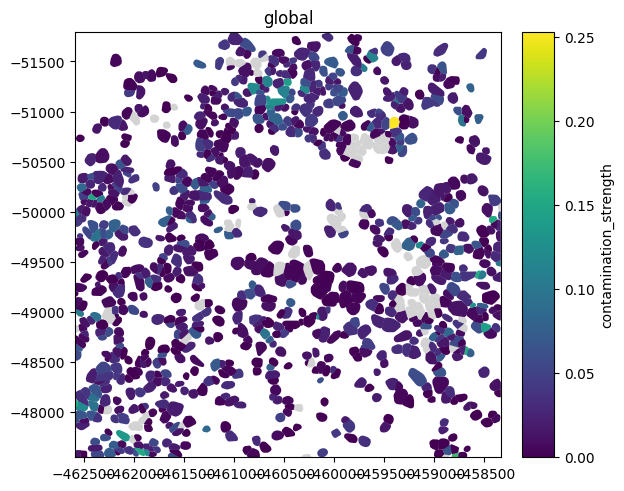

In [28]:
sdata.pl.render_shapes(color='contamination_strength').pl.show()

We can see that a region towards the top of the sample is particularly affected. How you use this information in the end depends on your research question. For example, you could try different segmentation methods, remove those cells, or be extra careful about plasma cell contamination when evaluating results.

# 6. Play around

We have gone through two of `SegTraQ`'s modules here. But there are many more that look at other aspects of segmentation quality, from subcelluar distribution of transcripts to clustering stability. Have a look at the [documentation](https://lazdaria.github.io/SegTraQ/index.html), and feel free to play around with the data!